# FairPay AI: Market Salary Benchmarking Engine  
## Supplementary Extension: Compensation Anomaly Detection and Pay Risk Monitor

This notebook builds a compensation analytics pipeline to estimate benchmark salary and flag unusual pay cases.

Project workflow:
1. Load and audit the salary dataset  
2. Clean the data and engineer features  
3. Audit the impact of duplicate rows  
4. Train salary benchmark models  
5. Select the best benchmark model  
6. Generate salary predictions on a held-out test year  
7. Flag unusual compensation records using multiple anomaly signals  
8. Save outputs for reporting and dashboard use

### Business framing

The anchor project estimates fair-market salary in USD using role, experience, geography, company, and work arrangement features.

The supplementary extension identifies under-market pay, over-market pay, and unusual compensation outliers using model-based and peer-based signals.

## Notebook roadmap

This notebook is designed to run top to bottom in Jupyter or VS Code.

Key design choices:
- `salary_in_usd` is used as the target because it is the standardized compensation field.
- `remote_ratio` is treated as categorical.
- Both a raw dataset and a deduplicated dataset are evaluated.
- A time-aware split is used so the latest year becomes the holdout test set.
- Log salary is modeled to reduce right-skew.
- The anomaly extension is tied directly to benchmark model outputs.

In [1]:

# =========================
# 1. Setup and configuration
# =========================

# If CatBoost is not installed in your environment, run the next line once:
# %pip install catboost

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False

# -------------------------
# Local file path
# -------------------------
FILE_PATH = r"C:\Users\abals\Desktop\Coding Projects\Data\salaries.csv"

# If you convert the dataset to Excel later, use this instead:
# FILE_PATH = r"C:\Users\abals\Desktop\Coding Projects\Data\salaries.xlsx"
# df = pd.read_excel(FILE_PATH)

# -------------------------
# Project settings
# -------------------------
RANDOM_STATE = 42
TEST_YEAR = 2025
RARE_TITLE_THRESHOLD = 20
USE_DEDUP_DATA = True

ZSCORE_THRESHOLD = 2.5
PEER_GAP_THRESHOLD = 0.75
ISOFORST_CONTAMINATION = 0.02

OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"
PRED_DIR = OUTPUT_DIR / "predictions"

for folder in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, METRIC_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("CatBoost available:", CATBOOST_AVAILABLE)
print("Output folder:", OUTPUT_DIR.resolve())


CatBoost available: False
Output folder: C:\Users\abals\Desktop\Coding Projects\black_vault\outputs



## Load the data

We start by reading the CSV and taking a quick look at the structure.


In [2]:

# =========================
# 2. Load the data
# =========================

df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (151445, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M



## Initial data audit

This section answers the first business and modeling questions:

- How large is the dataset?
- Are there missing values?
- How many unique categories do we have?
- How severe is duplication?
- Which columns are high-cardinality and may need special handling?


In [3]:

# =========================
# 3. Initial audit
# =========================

print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values by column:")
display(df.isnull().sum().to_frame("missing_count"))

summary_rows = []
for col in df.columns:
    summary_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "unique_values": df[col].nunique(dropna=False),
        "missing_values": int(df[col].isnull().sum())
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["unique_values", "column"], ascending=[False, True])
display(summary_df)

duplicate_count = int(df.duplicated().sum())
rows_in_duplicate_groups = int(df[df.duplicated(keep=False)].shape[0])

audit_summary = pd.DataFrame({
    "metric": [
        "row_count",
        "column_count",
        "exact_duplicate_rows",
        "rows_in_duplicate_groups"
    ],
    "value": [
        int(df.shape[0]),
        int(df.shape[1]),
        duplicate_count,
        rows_in_duplicate_groups
    ]
})

display(audit_summary)


Data types:


,dtype
work_year,int64
experience_level,object
employment_type,object
job_title,object
salary,int64
salary_currency,object
salary_in_usd,int64
employee_residence,object
remote_ratio,int64
company_location,object



Missing values by column:


,missing_count
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


,column,dtype,unique_values,missing_values
6,salary_in_usd,int64,13580,0
4,salary,int64,12308,0
3,job_title,object,422,0
7,employee_residence,object,104,0
9,company_location,object,97,0
5,salary_currency,object,26,0
0,work_year,int64,6,0
2,employment_type,object,4,0
1,experience_level,object,4,0
10,company_size,object,3,0


,metric,value
0,row_count,151445
1,column_count,11
2,exact_duplicate_rows,79532
3,rows_in_duplicate_groups,102375



## Quick category distributions

These distributions help us see imbalance before modeling.  
That matters because some targets and predictors are highly skewed.


In [4]:

# =========================
# 4. Quick categorical distributions
# =========================

for col in ["work_year", "experience_level", "employment_type", "remote_ratio", "company_size"]:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts(dropna=False).rename_axis(col).reset_index(name="count"))



Value counts for work_year:


,work_year,count
0,2025,78726
1,2024,62241
2,2023,8524
3,2022,1661
4,2021,218
5,2020,75



Value counts for experience_level:


,experience_level,count
0,SE,87491
1,MI,46128
2,EN,13663
3,EX,4163



Value counts for employment_type:


,employment_type,count
0,FT,150541
1,CT,467
2,PT,421
3,FL,16



Value counts for remote_ratio:


,remote_ratio,count
0,0,119570
1,100,31546
2,50,329



Value counts for company_size:


,company_size,count
0,M,147302
1,L,3926
2,S,217



## Clean the data and engineer project features

This is where we implement the design choices from the project plan:

- clean text columns
- treat `remote_ratio` as categorical
- remove invalid target values
- create a deduplicated version
- group rare job titles
- create a same-country flag
- create a job-title frequency feature
- create a log-transformed salary target


In [5]:

# =========================
# 5. Cleaning + feature engineering
# =========================

df = df.copy()
df.columns = df.columns.str.strip()

# Standardize text columns
text_cols = [
    "experience_level",
    "employment_type",
    "job_title",
    "salary_currency",
    "employee_residence",
    "company_location",
    "company_size"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Ensure expected dtypes
df["work_year"] = df["work_year"].astype(int)
df["remote_ratio"] = df["remote_ratio"].astype(str)
df["salary_in_usd"] = pd.to_numeric(df["salary_in_usd"], errors="coerce")

# Remove invalid target values if any exist
df = df[df["salary_in_usd"].notna()].copy()
df = df[df["salary_in_usd"] > 0].copy()

# Engineer job title grouping
title_counts = df["job_title"].value_counts()
rare_titles = title_counts[title_counts < RARE_TITLE_THRESHOLD].index
df["job_title_grouped"] = df["job_title"].replace(rare_titles, "Other_Rare_Title")

# Engineer same-country flag
df["same_country_flag"] = (df["employee_residence"] == df["company_location"]).astype(int)

# Engineer title frequency
title_freq = df["job_title_grouped"].value_counts(normalize=True)
df["job_title_freq"] = df["job_title_grouped"].map(title_freq)

# Engineer log target
df["log_salary_in_usd"] = np.log1p(df["salary_in_usd"])

# Keep two versions for modeling decisions
raw_df = df.copy()
dedup_df = df.drop_duplicates().copy()

print("Raw shape after cleaning:", raw_df.shape)
print("Deduplicated shape:", dedup_df.shape)

feature_cols = [
    "work_year",
    "experience_level",
    "employment_type",
    "job_title_grouped",
    "employee_residence",
    "remote_ratio",
    "company_location",
    "company_size",
    "same_country_flag",
    "job_title_freq"
]

target_col = "log_salary_in_usd"

numeric_features = ["work_year", "same_country_flag", "job_title_freq"]
categorical_features = [
    "experience_level",
    "employment_type",
    "job_title_grouped",
    "employee_residence",
    "remote_ratio",
    "company_location",
    "company_size"
]

print("\nModel features:")
display(pd.DataFrame({"feature": feature_cols}))


Raw shape after cleaning: (151445, 15)
Deduplicated shape: (71913, 15)

Model features:


,feature
0,work_year
1,experience_level
2,employment_type
3,job_title_grouped
4,employee_residence
5,remote_ratio
6,company_location
7,company_size
8,same_country_flag
9,job_title_freq



## Duplicate impact audit

A large duplicate count can artificially help a model if identical records leak across train and test periods.  
To audit that risk, we compare a simple benchmark model on:

- the raw dataset
- the deduplicated dataset

This is a good modeling integrity check and a strong interview talking point.


In [6]:

# =========================
# 6. Duplicate impact audit using a simple Ridge benchmark
# =========================

def build_linear_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features)
        ]
    )

def evaluate_predictions(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def duplicate_audit_score(input_df, test_year=TEST_YEAR):
    train_df_local = input_df[input_df["work_year"] < test_year].copy()
    test_df_local = input_df[input_df["work_year"] == test_year].copy()

    if train_df_local.empty or test_df_local.empty:
        return None

    preprocessor = build_linear_preprocessor()
    model = Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=1.0))
    ])

    model.fit(train_df_local[feature_cols], train_df_local[target_col])
    pred_log = model.predict(test_df_local[feature_cols])
    metrics = evaluate_predictions(test_df_local[target_col], pred_log)

    return {
        "rows": len(input_df),
        "train_rows": len(train_df_local),
        "test_rows": len(test_df_local),
        **metrics
    }

duplicate_audit_results = pd.DataFrame({
    "raw_dataset": duplicate_audit_score(raw_df),
    "deduplicated_dataset": duplicate_audit_score(dedup_df)
}).T

display(duplicate_audit_results)


,rows,train_rows,test_rows,MAE,RMSE,R2
raw_dataset,151445.0,72719.0,78726.0,45372.558873,64616.642611,0.269430
deduplicated_dataset,71913.0,33631.0,38282.0,47174.681677,67318.990036,0.264639



## Select the modeling dataset and create the time-based split

The default setting in this notebook uses the **deduplicated dataset**.  
That makes the benchmark more conservative and more trustworthy.

The time split is:

- **Train:** all years before the holdout year
- **Test:** the holdout year only

This better simulates real forecasting than a random split.


In [7]:

# =========================
# 7. Choose modeling dataset + holdout split
# =========================

model_df = dedup_df.copy() if USE_DEDUP_DATA else raw_df.copy()

train_df = model_df[model_df["work_year"] < TEST_YEAR].copy()
test_df = model_df[model_df["work_year"] == TEST_YEAR].copy()

print("Using deduplicated data:" if USE_DEDUP_DATA else "Using raw data:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

display(train_df[["work_year"]].value_counts().reset_index(name="count").sort_values("work_year"))
display(test_df[["work_year"]].value_counts().reset_index(name="count").sort_values("work_year"))


Using deduplicated data:
Train shape: (33631, 15)
Test shape: (38282, 15)


,work_year,count
4,2020,75
3,2021,214
2,2022,1114
1,2023,4538
0,2024,27690


,work_year,count
0,2025,38282



## Focused EDA for business understanding

This is not meant to be a full EDA notebook.  
The goal here is to produce the most useful visuals for model reasoning:

- salary distribution
- salary by experience level
- salary by work year
- top titles by frequency
- top titles by median salary with a minimum support filter


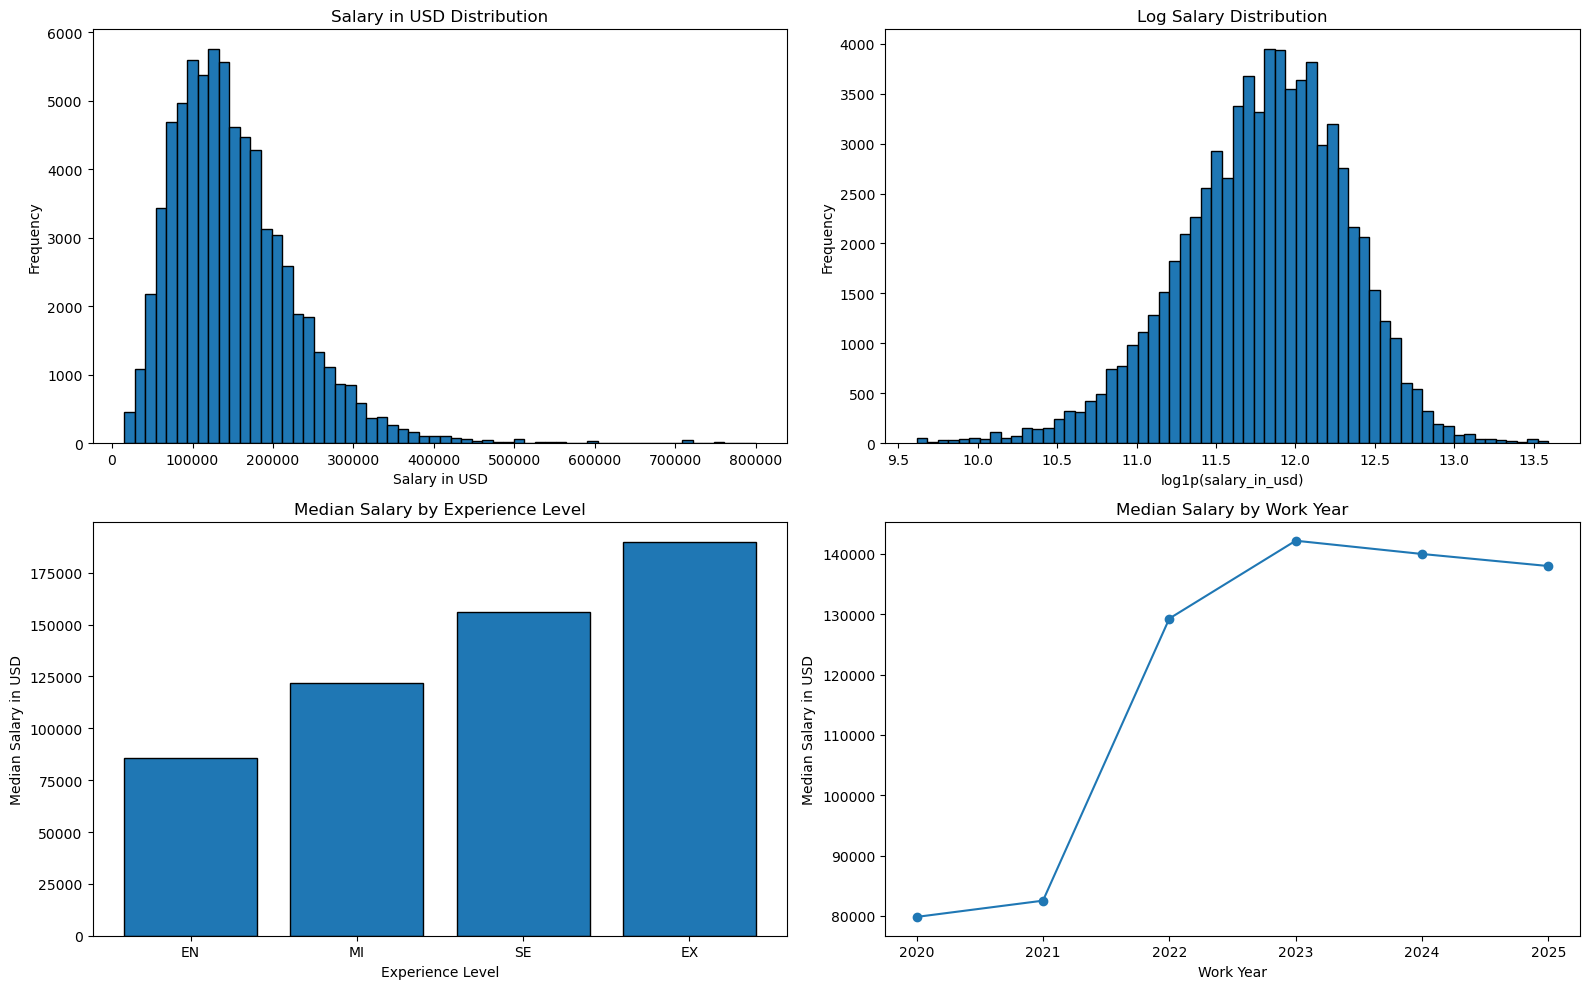

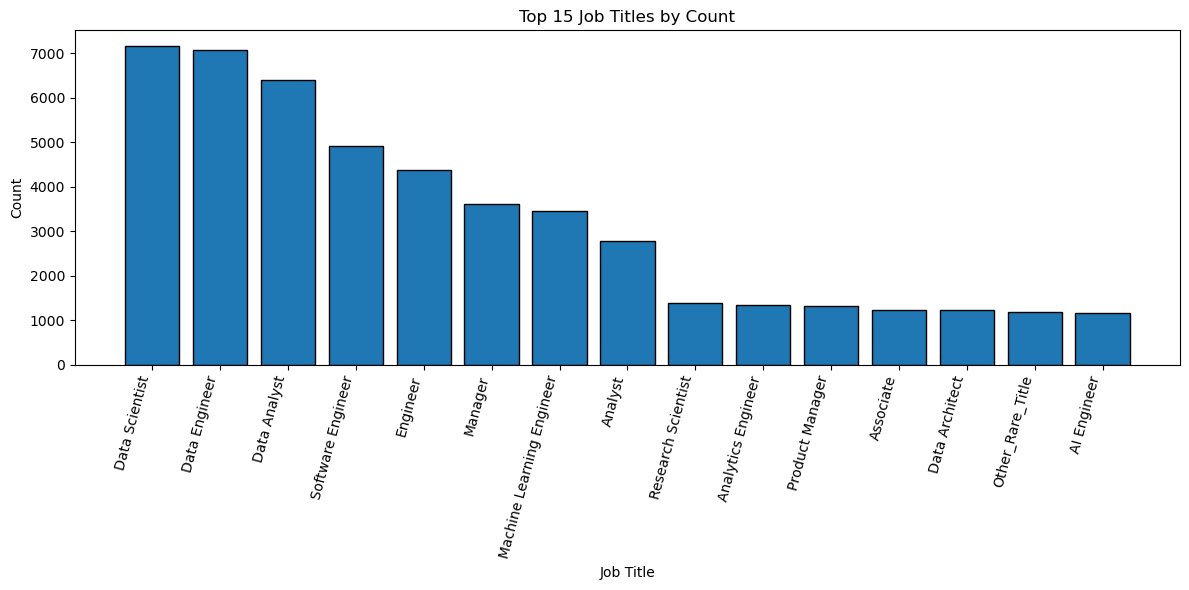

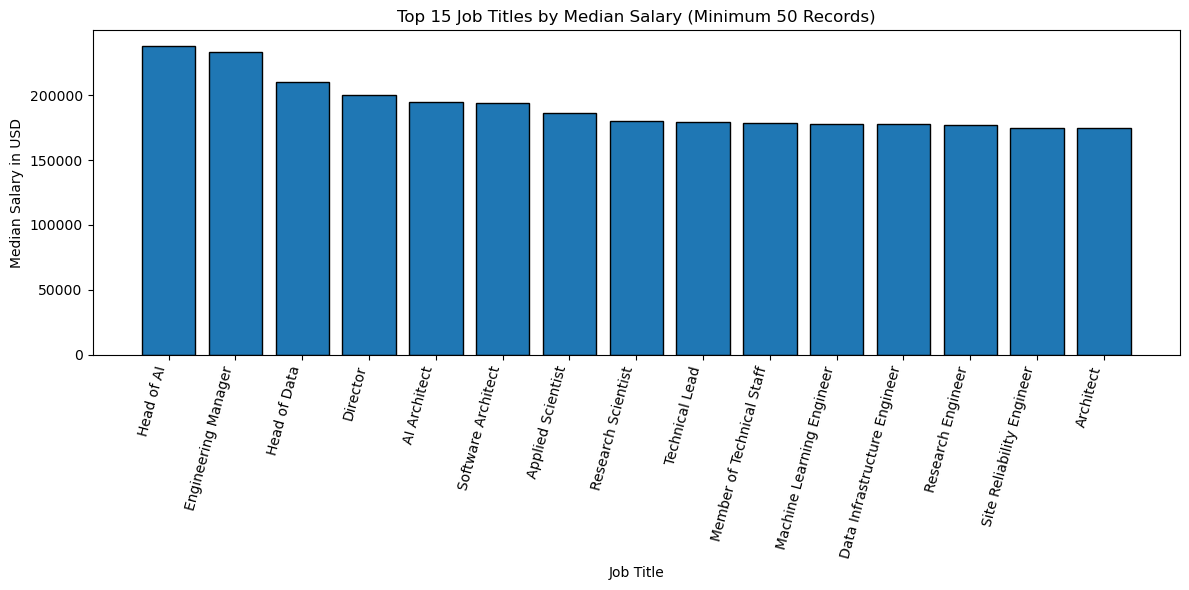

,job_title_grouped,median,count
113,Head of AI,238000.0,59
107,Engineering Manager,233500.0,524
114,Head of Data,210000.0,247
100,Director,200000.0,512
0,AI Architect,195000.0,215
167,Software Architect,193800.0,57
18,Applied Scientist,186200.0,561
158,Research Scientist,180000.0,1381
183,Technical Lead,179170.0,182
130,Member of Technical Staff,178150.0,70


In [8]:

# =========================
# 8. Focused EDA
# =========================

eda_df = model_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: salary distribution
axes[0, 0].hist(eda_df["salary_in_usd"], bins=60, edgecolor="black")
axes[0, 0].set_title("Salary in USD Distribution")
axes[0, 0].set_xlabel("Salary in USD")
axes[0, 0].set_ylabel("Frequency")

# Plot 2: log salary distribution
axes[0, 1].hist(eda_df["log_salary_in_usd"], bins=60, edgecolor="black")
axes[0, 1].set_title("Log Salary Distribution")
axes[0, 1].set_xlabel("log1p(salary_in_usd)")
axes[0, 1].set_ylabel("Frequency")

# Plot 3: median salary by experience level
exp_medians = (
    eda_df.groupby("experience_level")["salary_in_usd"]
    .median()
    .reindex(["EN", "MI", "SE", "EX"])
)
axes[1, 0].bar(exp_medians.index.astype(str), exp_medians.values, edgecolor="black")
axes[1, 0].set_title("Median Salary by Experience Level")
axes[1, 0].set_xlabel("Experience Level")
axes[1, 0].set_ylabel("Median Salary in USD")

# Plot 4: median salary by year
year_medians = eda_df.groupby("work_year")["salary_in_usd"].median().sort_index()
axes[1, 1].plot(year_medians.index, year_medians.values, marker="o")
axes[1, 1].set_title("Median Salary by Work Year")
axes[1, 1].set_xlabel("Work Year")
axes[1, 1].set_ylabel("Median Salary in USD")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_core_views.png", dpi=150, bbox_inches="tight")
plt.show()

# Top titles by count
top_title_counts = eda_df["job_title_grouped"].value_counts().head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_title_counts.index, top_title_counts.values, edgecolor="black")
plt.title("Top 15 Job Titles by Count")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_titles_by_count.png", dpi=150, bbox_inches="tight")
plt.show()

# Top titles by median salary with minimum support
title_stats = (
    eda_df.groupby("job_title_grouped")["salary_in_usd"]
    .agg(["median", "count"])
    .reset_index()
)

top_median_titles = (
    title_stats[title_stats["count"] >= 50]
    .sort_values("median", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
plt.bar(top_median_titles["job_title_grouped"], top_median_titles["median"], edgecolor="black")
plt.title("Top 15 Job Titles by Median Salary (Minimum 50 Records)")
plt.xlabel("Job Title")
plt.ylabel("Median Salary in USD")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_titles_by_median_salary.png", dpi=150, bbox_inches="tight")
plt.show()

display(top_median_titles)



## Build benchmark models

We train the anchor salary benchmark in layers:

1. **DummyRegressor** — simple baseline  
2. **Ridge regression** — linear benchmark with one-hot encoded categorical variables  
3. **CatBoostRegressor** — strong tabular benchmark that handles categorical features well  

All models are evaluated on the **actual salary scale**, even though training happens on log salary.


In [9]:

# =========================
# 9. Helper functions for modeling
# =========================

def fit_and_score_sklearn_model(model_name, model, X_train, y_train, X_test, y_test):
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    pred_log = fitted_model.predict(X_test)

    metrics = evaluate_predictions(y_test, pred_log)
    result = {
        "model_name": model_name,
        **metrics
    }
    return fitted_model, pred_log, result

linear_preprocessor = build_linear_preprocessor()

dummy_model = Pipeline([
    ("prep", linear_preprocessor),
    ("model", DummyRegressor(strategy="median"))
])

ridge_model = Pipeline([
    ("prep", linear_preprocessor),
    ("model", Ridge(alpha=1.0))
])


In [10]:

# =========================
# 10. Train the baseline models
# =========================

trained_models = {}
prediction_logs = {}
model_results = []

# Dummy baseline
dummy_fitted, dummy_pred_log, dummy_result = fit_and_score_sklearn_model(
    "DummyRegressor",
    dummy_model,
    X_train, y_train, X_test, y_test
)
trained_models["DummyRegressor"] = dummy_fitted
prediction_logs["DummyRegressor"] = dummy_pred_log
model_results.append(dummy_result)

# Ridge benchmark
ridge_fitted, ridge_pred_log, ridge_result = fit_and_score_sklearn_model(
    "Ridge",
    ridge_model,
    X_train, y_train, X_test, y_test
)
trained_models["Ridge"] = ridge_fitted
prediction_logs["Ridge"] = ridge_pred_log
model_results.append(ridge_result)

# CatBoost benchmark (recommended anchor model if available)
if CATBOOST_AVAILABLE:
    X_train_cat = X_train.copy()
    X_test_cat = X_test.copy()

    for col in categorical_features:
        X_train_cat[col] = X_train_cat[col].astype(str)
        X_test_cat[col] = X_test_cat[col].astype(str)

    cat_model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=150,
        learning_rate=0.08,
        depth=8,
        l2_leaf_reg=5,
        random_seed=RANDOM_STATE,
        verbose=False
    )

    cat_model.fit(
        X_train_cat,
        y_train,
        cat_features=categorical_features,
        eval_set=(X_test_cat, y_test),
        use_best_model=True,
        early_stopping_rounds=30,
        verbose=False
    )

    cat_pred_log = cat_model.predict(X_test_cat)
    cat_result = {
        "model_name": "CatBoostRegressor",
        **evaluate_predictions(y_test, cat_pred_log)
    }

    trained_models["CatBoostRegressor"] = cat_model
    prediction_logs["CatBoostRegressor"] = cat_pred_log
    model_results.append(cat_result)

model_results_df = pd.DataFrame(model_results).sort_values("MAE").reset_index(drop=True)
display(model_results_df)

model_results_df.to_csv(METRIC_DIR / "model_comparison.csv", index=False)


,model_name,MAE,RMSE,R2
0,Ridge,47174.681677,67318.990036,0.264639
1,DummyRegressor,58200.322031,79420.866896,-0.023515



## Select the best benchmark model

The project anchor should be the strongest practical salary benchmark.  
By default, we choose the model with the lowest **MAE** on the holdout year.


In [11]:

# =========================
# 11. Select the best model
# =========================

best_model_name = model_results_df.iloc[0]["model_name"]
best_model = trained_models[best_model_name]
best_pred_log = prediction_logs[best_model_name]

print("Selected best model:", best_model_name)
display(model_results_df)


Selected best model: Ridge


,model_name,MAE,RMSE,R2
0,Ridge,47174.681677,67318.990036,0.264639
1,DummyRegressor,58200.322031,79420.866896,-0.023515



## Feature interpretation

Interpretability is important because this project is meant to be explained in interviews.

- If CatBoost is the best model, we use built-in feature importance.
- If Ridge is the best model, we inspect the largest absolute coefficients.


Top Ridge coefficients by absolute size:


,feature,coefficient,abs_coefficient
231,cat__employee_residence_NG,-0.813194,0.813194
187,cat__employee_residence_CN,0.782653,0.782653
105,cat__job_title_grouped_Engineering Manager,0.619083,0.619083
324,cat__company_location_NG,0.609516,0.609516
103,cat__job_title_grouped_Encounter Data Manageme...,-0.576043,0.576043
209,cat__employee_residence_HU,-0.560005,0.560005
194,cat__employee_residence_DO,0.524837,0.524837
145,cat__job_title_grouped_Research Assistant,-0.524539,0.524539
77,cat__job_title_grouped_Data Operations Specialist,-0.514342,0.514342
282,cat__company_location_CL,-0.497256,0.497256


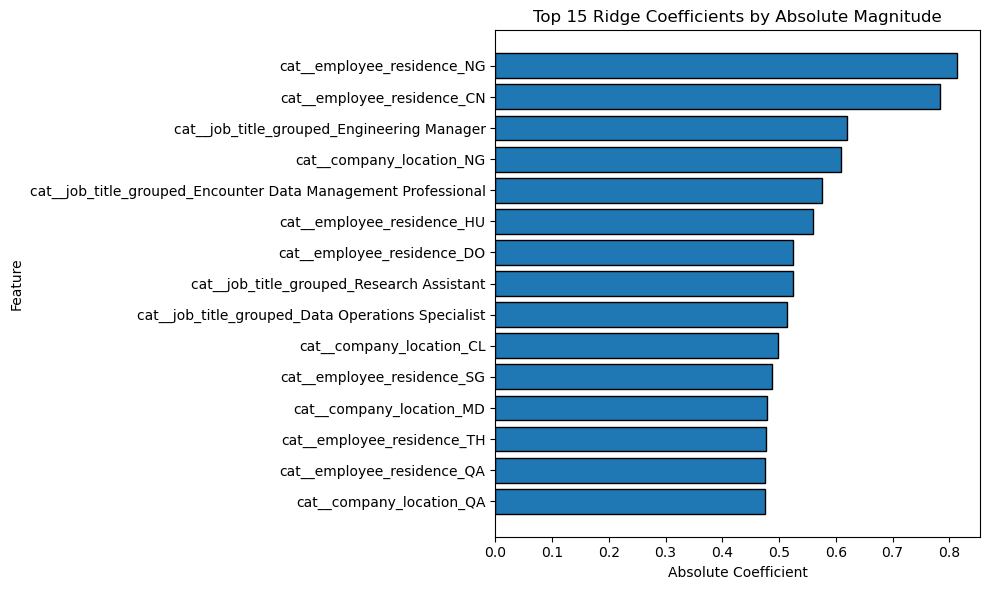

In [12]:

# =========================
# 12. Model interpretation
# =========================

if best_model_name == "CatBoostRegressor":
    feature_importance_df = best_model.get_feature_importance(prettified=True)
    feature_importance_df.columns = ["feature", "importance"]
    feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)

    print("Top feature importances from CatBoost:")
    display(feature_importance_df.head(15))

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df.head(15)["feature"][::-1], feature_importance_df.head(15)["importance"][::-1], edgecolor="black")
    plt.title("Top 15 CatBoost Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "catboost_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

elif best_model_name == "Ridge":
    prep = best_model.named_steps["prep"]
    ridge_estimator = best_model.named_steps["model"]

    feature_names = prep.get_feature_names_out()
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": ridge_estimator.coef_,
        "abs_coefficient": np.abs(ridge_estimator.coef_)
    }).sort_values("abs_coefficient", ascending=False)

    print("Top Ridge coefficients by absolute size:")
    display(coef_df.head(20))

    plt.figure(figsize=(10, 6))
    plt.barh(coef_df.head(15)["feature"][::-1], coef_df.head(15)["abs_coefficient"][::-1], edgecolor="black")
    plt.title("Top 15 Ridge Coefficients by Absolute Magnitude")
    plt.xlabel("Absolute Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ridge_top_coefficients.png", dpi=150, bbox_inches="tight")
    plt.show()

else:
    print("Interpretation block not defined for this model.")



## Build the benchmark prediction table

This table is the bridge between the main and supplementary projects.  
It combines:

- actual salary
- predicted salary
- residuals
- percentage errors

This table becomes the base for anomaly detection and business reporting.


In [13]:

# =========================
# 13. Create benchmark prediction table
# =========================

results = test_df[[
    "work_year",
    "experience_level",
    "employment_type",
    "job_title",
    "job_title_grouped",
    "employee_residence",
    "remote_ratio",
    "company_location",
    "company_size",
    "same_country_flag",
    "job_title_freq",
    "salary_in_usd"
]].copy()

results = results.rename(columns={"salary_in_usd": "actual_salary"})
results["predicted_salary"] = np.expm1(best_pred_log)
results["residual"] = results["actual_salary"] - results["predicted_salary"]
results["abs_residual"] = results["residual"].abs()
results["pct_error"] = results["residual"] / results["actual_salary"].replace(0, np.nan)
results["abs_pct_error"] = results["pct_error"].abs()

display(results.head())

results.to_csv(PRED_DIR / "salary_benchmark_predictions.csv", index=False)
print("Saved:", (PRED_DIR / "salary_benchmark_predictions.csv").resolve())


,work_year,experience_level,employment_type,job_title,job_title_grouped,employee_residence,remote_ratio,company_location,company_size,same_country_flag,job_title_freq,actual_salary,predicted_salary,residual,abs_residual,pct_error,abs_pct_error
0,2025,EX,FT,Head of Data,Head of Data,US,0,US,M,1,0.002219,348516,247732.406699,100783.593301,100783.593301,0.289179,0.289179
1,2025,EX,FT,Head of Data,Head of Data,US,0,US,M,1,0.002219,232344,247732.406699,-15388.406699,15388.406699,-0.066231,0.066231
2,2025,SE,FT,Data Scientist,Data Scientist,US,0,US,M,1,0.123814,145400,168518.281200,-23118.281200,23118.281200,-0.158998,0.158998
3,2025,SE,FT,Data Scientist,Data Scientist,US,0,US,M,1,0.123814,81600,168518.281200,-86918.281200,86918.281200,-1.065175,1.065175
4,2025,MI,FT,Engineer,Engineer,US,100,US,M,1,0.072660,160000,136084.134939,23915.865061,23915.865061,0.149474,0.149474


Saved: C:\Users\abals\Desktop\Coding Projects\black_vault\outputs\predictions\salary_benchmark_predictions.csv



## Visual check: actual vs predicted salary

This plot helps us see general benchmark quality and whether errors are widening at higher salary levels.


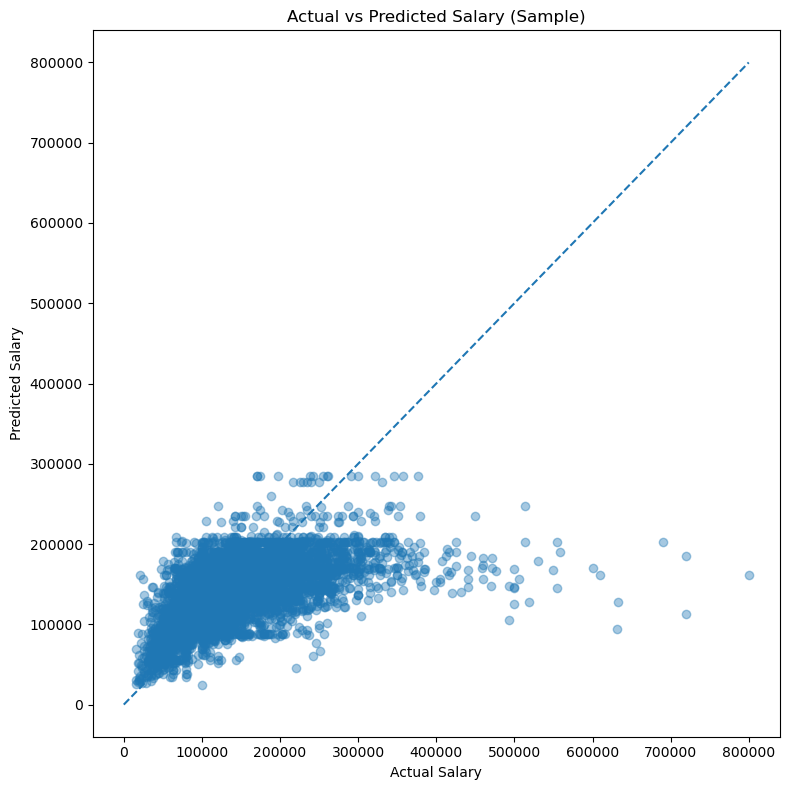

In [14]:

# =========================
# 14. Visualize actual vs predicted salary
# =========================

plot_sample = results.sample(min(5000, len(results)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 8))
plt.scatter(plot_sample["actual_salary"], plot_sample["predicted_salary"], alpha=0.4)
max_val = max(plot_sample["actual_salary"].max(), plot_sample["predicted_salary"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.title("Actual vs Predicted Salary (Sample)")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted_salary.png", dpi=150, bbox_inches="tight")
plt.show()



## Compensation anomaly detection

This supplementary extension uses **three anomaly signals**:

1. **Residual z-score** — the salary differs strongly from the model benchmark  
2. **Peer-group gap** — the salary differs strongly from similar peer groups  
3. **Isolation Forest** — an unsupervised outlier signal using residual behavior  

We then combine these into a simple **anomaly score**.


In [15]:

# =========================
# 15. Anomaly detection
# =========================

# Residual-based anomaly signal
residual_mean = results["residual"].mean()
residual_std = results["residual"].std() if results["residual"].std() != 0 else 1

results["residual_zscore"] = (results["residual"] - residual_mean) / residual_std
results["zscore_anomaly_flag"] = (results["residual_zscore"].abs() >= ZSCORE_THRESHOLD).astype(int)

# Peer benchmark using train data
peer_group_cols = ["job_title_grouped", "experience_level", "company_location"]

peer_stats = (
    train_df.groupby(peer_group_cols)["salary_in_usd"]
    .agg(peer_median="median", peer_count="size")
    .reset_index()
)

fallback_peer_stats = (
    train_df.groupby(["job_title_grouped", "experience_level"])["salary_in_usd"]
    .median()
    .reset_index(name="peer_median_fallback")
)

results = results.merge(peer_stats, how="left", on=peer_group_cols)
results = results.merge(fallback_peer_stats, how="left", on=["job_title_grouped", "experience_level"])

results["peer_median_final"] = results["peer_median"].fillna(results["peer_median_fallback"])
results["peer_gap_pct"] = (
    (results["actual_salary"] - results["peer_median_final"]) /
    results["peer_median_final"]
)

results["peer_anomaly_flag"] = results["peer_gap_pct"].abs().ge(PEER_GAP_THRESHOLD).fillna(False).astype(int)

# Isolation Forest using model error behavior
anomaly_features = results[[
    "actual_salary",
    "predicted_salary",
    "residual",
    "abs_residual",
    "abs_pct_error"
]].copy()

anomaly_features = anomaly_features.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
anomaly_features_scaled = scaler.fit_transform(anomaly_features)

iso_model = IsolationForest(
    n_estimators=200,
    contamination=ISOFORST_CONTAMINATION,
    random_state=RANDOM_STATE
)

results["iso_pred"] = iso_model.fit_predict(anomaly_features_scaled)
results["isoforest_anomaly_flag"] = (results["iso_pred"] == -1).astype(int)

# Combined anomaly score
results["anomaly_score"] = results[[
    "zscore_anomaly_flag",
    "peer_anomaly_flag",
    "isoforest_anomaly_flag"
]].sum(axis=1)

# Business interpretation flags
results["under_market_flag"] = ((results["residual"] < 0) & (results["anomaly_score"] >= 1)).astype(int)
results["over_market_flag"] = ((results["residual"] > 0) & (results["anomaly_score"] >= 1)).astype(int)
results["priority_anomaly_flag"] = (results["anomaly_score"] >= 2).astype(int)

anomaly_summary = pd.DataFrame({
    "metric": [
        "zscore_anomaly_rate",
        "peer_anomaly_rate",
        "isolation_forest_anomaly_rate",
        "priority_anomaly_rate",
        "under_market_rate",
        "over_market_rate"
    ],
    "value": [
        results["zscore_anomaly_flag"].mean(),
        results["peer_anomaly_flag"].mean(),
        results["isoforest_anomaly_flag"].mean(),
        results["priority_anomaly_flag"].mean(),
        results["under_market_flag"].mean(),
        results["over_market_flag"].mean()
    ]
})

display(anomaly_summary)


,metric,value
0,zscore_anomaly_rate,0.021080
1,peer_anomaly_rate,0.074578
2,isolation_forest_anomaly_rate,0.020009
3,priority_anomaly_rate,0.022282
4,under_market_rate,0.010736
5,over_market_rate,0.071574



## Review the highest-priority anomaly cases

These tables are usually the most business-friendly outputs:

- **Top under-market cases**: actual salary far below the benchmark  
- **Top over-market cases**: actual salary far above the benchmark


In [16]:

# =========================
# 16. Review anomaly cases
# =========================

priority_results = results[results["priority_anomaly_flag"] == 1].copy()

top_under_market = (
    priority_results[priority_results["under_market_flag"] == 1]
    .sort_values("residual")
    .head(20)
)

top_over_market = (
    priority_results[priority_results["over_market_flag"] == 1]
    .sort_values("residual", ascending=False)
    .head(20)
)

print("Top under-market cases:")
display(top_under_market[[
    "job_title",
    "experience_level",
    "company_location",
    "employee_residence",
    "remote_ratio",
    "actual_salary",
    "predicted_salary",
    "residual",
    "anomaly_score"
]])

print("Top over-market cases:")
display(top_over_market[[
    "job_title",
    "experience_level",
    "company_location",
    "employee_residence",
    "remote_ratio",
    "actual_salary",
    "predicted_salary",
    "residual",
    "anomaly_score"
]])


Top under-market cases:


,job_title,experience_level,company_location,employee_residence,remote_ratio,actual_salary,predicted_salary,residual,anomaly_score
31882,Head of Data,EX,US,US,100,25000,240565.976947,-215565.976947,3
15499,Engineer,EX,US,US,0,20538,203033.057913,-182495.057913,3
24861,Engineering Manager,SE,US,US,0,107300,284954.018855,-177654.018855,2
24207,Head of Data,EX,US,US,0,79100,247732.406699,-168632.406699,2
14357,Systems Engineer,SE,US,US,0,21950,178351.318521,-156401.318521,2
34661,Software Engineer,SE,US,US,100,30000,184771.224171,-154771.224171,2
27089,Applied Scientist,SE,CA,CA,100,22000,171338.902943,-149338.902943,2
16858,Manager,SE,US,US,0,31000,179126.821691,-148126.821691,2
36270,Engineer,EX,US,US,0,56000,203033.057913,-147033.057913,2
32608,Machine Learning Engineer,MI,US,US,0,20833,166917.250957,-146084.250957,2


Top over-market cases:


,job_title,experience_level,company_location,employee_residence,remote_ratio,actual_salary,predicted_salary,residual,anomaly_score
35576,Data Engineer,EN,AT,AT,0,793136,52985.526380,740150.473620,3
18836,Architect,SE,US,US,0,800000,161665.569517,638334.430483,3
23310,Analytics Engineer,MI,US,US,100,750000,135277.583442,614722.416558,3
29160,Software Engineer,SE,US,US,0,800000,190275.542267,609724.457733,3
35566,Data Visualization Engineer,MI,US,US,100,720000,113099.456345,606900.543655,3
36528,Data Visualization Engineer,MI,US,US,0,720000,116468.690500,603531.309500,3
22000,Software Engineer,MI,US,US,100,750000,152330.023410,597669.976590,3
10109,Software Engineer,MI,US,US,0,750000,156867.926293,593132.073707,3
33707,Data Engineer,MI,US,US,100,720000,128989.212490,591010.787510,3
15732,Machine Learning Engineer,MI,US,US,100,750000,162088.641301,587911.358699,3



## Visualize anomaly behavior

These visuals help communicate the supplementary project clearly in interviews and dashboards.


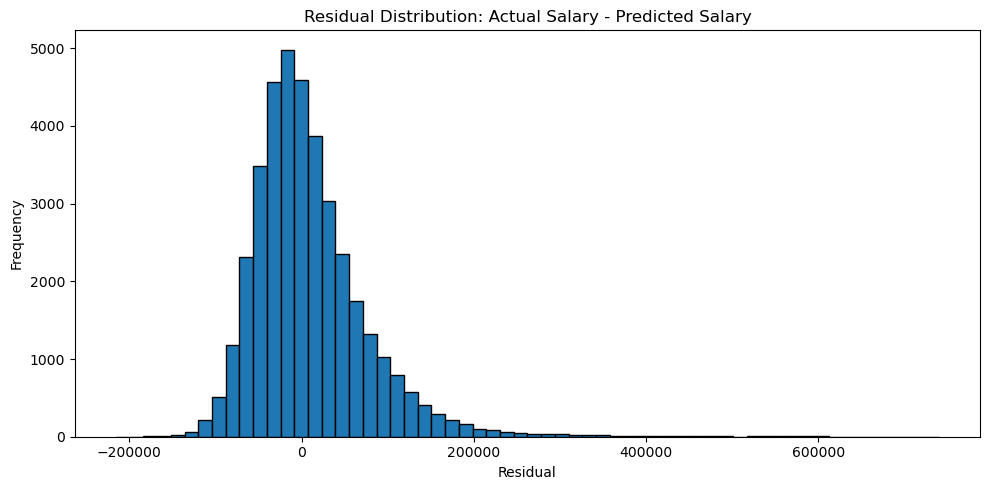

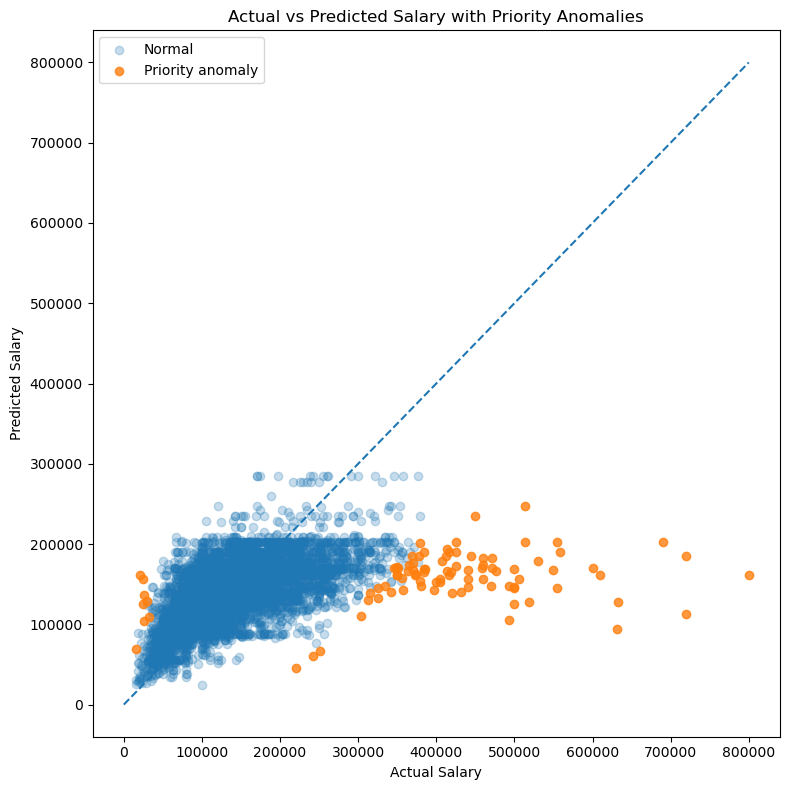

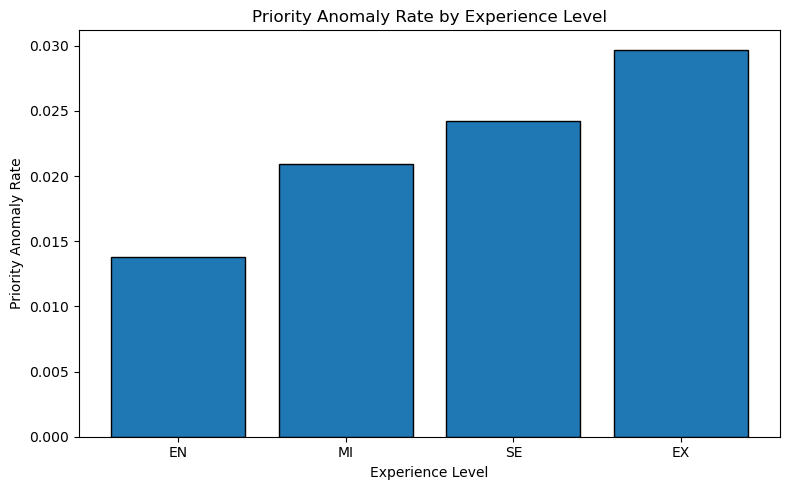

In [17]:

# =========================
# 17. Anomaly visuals
# =========================

# Residual histogram
plt.figure(figsize=(10, 5))
plt.hist(results["residual"], bins=60, edgecolor="black")
plt.title("Residual Distribution: Actual Salary - Predicted Salary")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "residual_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Scatter with priority anomalies highlighted
plot_results = results.sample(min(5000, len(results)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 8))
normal_points = plot_results[plot_results["priority_anomaly_flag"] == 0]
priority_points = plot_results[plot_results["priority_anomaly_flag"] == 1]

plt.scatter(normal_points["actual_salary"], normal_points["predicted_salary"], alpha=0.25, label="Normal")
plt.scatter(priority_points["actual_salary"], priority_points["predicted_salary"], alpha=0.8, label="Priority anomaly")

max_val = max(plot_results["actual_salary"].max(), plot_results["predicted_salary"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.title("Actual vs Predicted Salary with Priority Anomalies")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "anomaly_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# Anomaly counts by experience level
anomaly_by_exp = (
    results.groupby("experience_level")["priority_anomaly_flag"]
    .mean()
    .reindex(["EN", "MI", "SE", "EX"])
)

plt.figure(figsize=(8, 5))
plt.bar(anomaly_by_exp.index.astype(str), anomaly_by_exp.values, edgecolor="black")
plt.title("Priority Anomaly Rate by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Priority Anomaly Rate")
plt.tight_layout()
plt.savefig(FIG_DIR / "priority_anomaly_rate_by_experience.png", dpi=150, bbox_inches="tight")
plt.show()



## Save the main output tables

These files are useful for:
- GitHub project artifacts
- dashboard feeds
- report writing
- recruiter demos


In [18]:

# =========================
# 18. Save output tables
# =========================

results.to_csv(PRED_DIR / "salary_benchmark_with_anomalies.csv", index=False)
top_under_market.to_csv(PRED_DIR / "top_under_market_cases.csv", index=False)
top_over_market.to_csv(PRED_DIR / "top_over_market_cases.csv", index=False)
duplicate_audit_results.to_csv(METRIC_DIR / "duplicate_audit_results.csv")

saved_files = pd.DataFrame({
    "file": [
        str(METRIC_DIR / "model_comparison.csv"),
        str(METRIC_DIR / "duplicate_audit_results.csv"),
        str(PRED_DIR / "salary_benchmark_predictions.csv"),
        str(PRED_DIR / "salary_benchmark_with_anomalies.csv"),
        str(PRED_DIR / "top_under_market_cases.csv"),
        str(PRED_DIR / "top_over_market_cases.csv")
    ]
})

display(saved_files)


,file
0,outputs\metrics\model_comparison.csv
1,outputs\metrics\duplicate_audit_results.csv
2,outputs\predictions\salary_benchmark_predictio...
3,outputs\predictions\salary_benchmark_with_anom...
4,outputs\predictions\top_under_market_cases.csv
5,outputs\predictions\top_over_market_cases.csv


## Final interpretation

This notebook produces two connected outputs:

### Salary benchmark model
A regression-based benchmark that estimates expected market salary for a role using job, location, company, and work arrangement features.

### Compensation anomaly monitor
A supplementary anomaly layer that flags unusual salaries using residual behavior, peer-group comparisons, and Isolation Forest.

### Project value

This project is structured as a compensation analytics workflow rather than a simple salary prediction exercise.  
It supports salary benchmarking, unusual pay detection, and compensation review using a time-based holdout framework and business-facing outputs such as predicted salary, residuals, peer gaps, and anomaly scores.